# Hands-On 5: Linear and tree regression

Worked responses accompany the same experiments.

In [1]:
from pathlib import Path
import os
import sys
try:
    import mlcourse.setup
except ModuleNotFoundError:
    bases = [Path(os.environ.get("MLCOURSE_ROOT", Path.cwd())), Path.cwd(), Path("/content/pp-machine-learning")]
    for base in bases:
        for candidate in (base.resolve(), *base.resolve().parents):
            if (candidate / "src/mlcourse/setup.py").is_file():
                sys.path.insert(0, str(candidate / "src"))
                break
        else:
            continue
        break
    else:
        raise RuntimeError("Course files not found. Open the extracted course repository or set MLCOURSE_ROOT to its location.") from None

In [2]:
from mlcourse.setup import setup_notebook
REPO_ROOT = setup_notebook()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from mlcourse.labs import load_course_data

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from mlcourse.labs import regression_metrics
from mlcourse.widgets import interactive_regression

## 1. Inspect a regression dataset

Load the Concrete dataset. Inspect `head()` and the ranges of `cement`, `age` and `strength_mpa`. Strength is measured in MPa.

**Prediction:** What changes when the target is continuous rather than a class label?

A prediction is a number, so its error has a magnitude rather than just a correct/incorrect label.

In [3]:
data = load_course_data('concrete')
display(data.head())
display(data[['cement', 'age', 'strength_mpa']].describe())

,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength_mpa
0,540.000,0.000,0.000,162.000,2.500,1040.000,676.000,28,79.990
1,540.000,0.000,0.000,162.000,2.500,1055.000,676.000,28,61.890
2,332.500,142.500,0.000,228.000,0.000,932.000,594.000,270,40.270
3,332.500,142.500,0.000,228.000,0.000,932.000,594.000,365,41.050
4,198.600,132.400,0.000,192.000,0.000,978.400,825.500,360,44.300


,cement,age,strength_mpa
count,1030.000,1030.000,1030.000
mean,281.168,45.662,35.818
std,104.506,63.170,16.706
min,102.000,1.000,2.330
25%,192.375,7.000,23.710
50%,272.900,28.000,34.445
75%,350.000,56.000,46.135
max,540.000,365.000,82.600


**Observation:** Identify the predictors and continuous target.

`cement` and `age` are the selected predictors; `strength_mpa` is the target. Its displayed range is 2.330 to 82.600 MPa.

**Explanation:** Why is classification accuracy unsuitable here?

Exact equality between a real-valued prediction and target is generally uninformative. Regression metrics quantify the size of their differences.

## 2. Create a holdout split

Use `cement` and `age` as predictors. Split once and reuse these observations throughout the comparison.

**Prediction:** Why should every model use the same split?

A shared split keeps the evaluation examples fixed so model differences are easier to interpret.

In [4]:
X = data[['cement', 'age']]
y = data.strength_mpa
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0)
print(f'Training rows: {len(X_train)}; test rows: {len(X_test)}')

Training rows: 721; test rows: 309


**Observation:** Record the sizes of both partitions.

There are 721 training rows and 309 test rows. These indices are reused for the two-feature and all-feature comparisons.

**Explanation:** How does reusing a split help compare model behaviour?

A different split could change the difficulty of the evaluated observations. This row-level holdout provides a bounded classroom comparison, not evidence about every possible future population.

## 3. Fit a line

Fit strength from `cement` alone. Plot the line and test observations.

**Prediction:** Can one line bend to fit different local trends?

No. Its slope is constant over the displayed feature range.

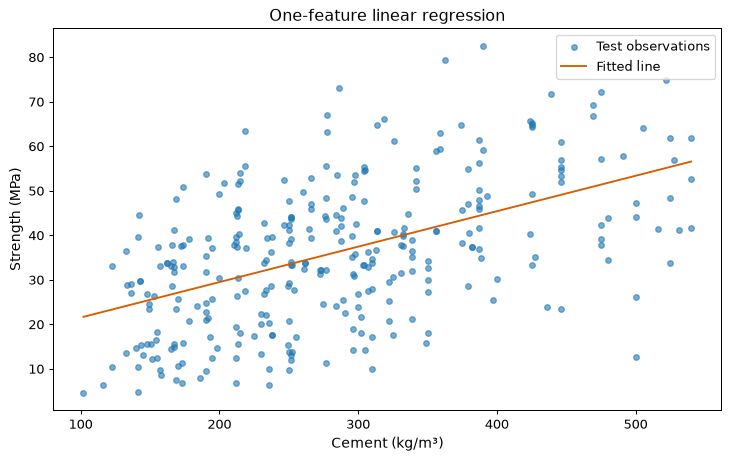

Slope: 0.080; intercept: 13.575


In [5]:
line = LinearRegression().fit(X_train[['cement']], y_train)
line_predictions = line.predict(X_test[['cement']])
ordered = X_test[['cement']].sort_values('cement')
fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
ax.scatter(X_test.cement, y_test, s=20, alpha=.6, label='Test observations')
ax.plot(ordered.cement, line.predict(ordered), color='#D55E00', label='Fitted line')
ax.set(xlabel='Cement (kg/m³)', ylabel='Strength (MPa)', title='One-feature linear regression')
ax.legend()
plt.show()
print(f'Slope: {line.coef_[0]:.3f}; intercept: {line.intercept_:.3f}')

**Observation:** Describe the spread around the fitted line.

The observations do not all lie on the line. The single slope summarises a global trend rather than each local fluctuation.

**Explanation:** Explain the restriction imposed by a global linear model.

A one-feature linear model permits only an affine relation. Additional variation in the target appears as residual error.

## 4. Measure regression error

Compute MSE and MAE for the line and a training-mean baseline.

**Prediction:** Which metric gives large errors more influence?

MSE squares the errors and therefore gives large deviations greater influence.

In [6]:
baseline = DummyRegressor(strategy='mean').fit(X_train, y_train)
error_table = pd.DataFrame({
    'Training mean': regression_metrics(y_test, baseline.predict(X_test)),
    'Linear model': regression_metrics(y_test, line_predictions),
}).T
display(error_table)

,MSE,MAE
Training mean,256.714,12.884
Linear model,189.211,11.372


**Observation:** Compare each metric with its baseline value.

The line reduces MSE from 256.714 to 189.211 and MAE from 12.884 to 11.372. It improves on the training-mean baseline under both metrics.

**Explanation:** Explain why MSE and MAE have different numerical scales.

MAE is measured in MPa while MSE is measured in squared MPa. Their magnitudes should be compared within each metric, not directly with one another.

## 5. Inspect residuals

Plot residuals against predictions, with a zero reference line.

**Prediction:** What would a systematic pattern in the residuals suggest?

A pattern would suggest that the model leaves structure unexplained by its current inputs and functional form.

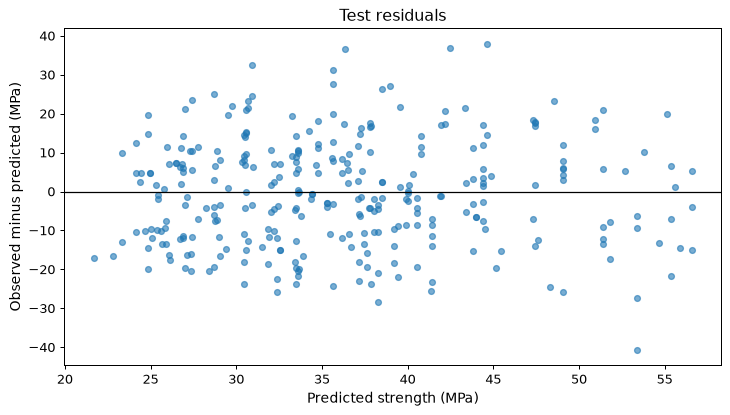

In [7]:
residuals = y_test - line_predictions
fig, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
ax.scatter(line_predictions, residuals, alpha=.6, s=22)
ax.axhline(0, color='black', linewidth=1)
ax.set(xlabel='Predicted strength (MPa)', ylabel='Observed minus predicted (MPa)', title='Test residuals')
plt.show()

**Observation:** Describe the spread and any visible pattern around zero.

Residuals have both signs, with several magnitudes near 40 MPa. The broad vertical spread shows that the fitted line leaves substantial variation unexplained.

**Explanation:** What can residuals reveal that one average error conceals?

An average combines errors across many observations. A residual plot can expose ranges where a global model systematically over- or under-predicts.

## 6. Compare a line, a plane and a tree

Add `age` to the linear model and compare it with a depth-three regression tree.

**Prediction:** How does a linear plane differ from a tree surface?

The plane has one constant slope per coordinate; the tree predicts a constant value within each region.

In [8]:
plane = LinearRegression().fit(X_train, y_train)
small_tree = DecisionTreeRegressor(max_depth=3, random_state=0).fit(X_train, y_train)
for name, model in [('Linear plane', plane), ('Depth-three tree', small_tree)]:
    error_table.loc[name] = regression_metrics(y_test, model.predict(X_test))
display(error_table)

,MSE,MAE
Training mean,256.714,12.884
Linear model,189.211,11.372
Linear plane,163.739,10.608
Depth-three tree,112.514,8.418


**Observation:** Compare the errors after adding a feature and changing the model family.

Adding `age` reduces linear-model MSE from 189.211 to 163.739. Keeping those two inputs and switching to the depth-three tree reduces it further to 112.514.

**Explanation:** Distinguish adding information from changing inductive bias.

More features can provide useful information without changing the linear family. A tree changes the representation itself by partitioning feature space.

## 7. Manipulate the fitted surfaces

Before moving `max_depth`, predict how the tree surface will change. Compare it with the linear surface.

**Prediction:** What happens to the number and size of constant regions as depth increases?

Greater depth permits more, smaller regions. Increasing `min_samples_leaf` constrains that refinement.

In [9]:
regression_lab = interactive_regression(X_train, X_test, y_train, y_test)
display(regression_lab.widget)

**Observation:** Record a setting with visibly finer partitions and its MSE.

With `min_samples_leaf=5`, increasing `max_depth` from `3` to `10` produces finer constant regions and changes tree MSE from 112.514 to 92.307. The linear plane remains unchanged at MSE 163.739.

**Explanation:** Explain the surface difference through the models' inductive biases.

The linear model constrains changes to global slopes. The tree uses successive axis-aligned splits, making predictions local and piecewise constant.

## 8. Make a bounded model comparison

Compare all-feature linear regression with depth-three and depth-ten trees on the same row split.

**Prediction:** Will the configuration with lowest training MSE also have lowest test MSE?

Not necessarily. A model can reduce training error by fitting detail that does not recur in held-out observations.

In [10]:
all_train = data.drop(columns='strength_mpa').loc[X_train.index]
all_test = data.drop(columns='strength_mpa').loc[X_test.index]
rows = []
for name, model in {'Linear': LinearRegression(),
    'Tree depth 3': DecisionTreeRegressor(max_depth=3, random_state=0),
    'Tree depth 10': DecisionTreeRegressor(max_depth=10, random_state=0)}.items():
    model.fit(all_train, y_train)
    rows.append({'model': name, 'train_MSE': regression_metrics(y_train, model.predict(all_train))['MSE'],
                 **{f'test_{key}': value for key, value in regression_metrics(y_test, model.predict(all_test)).items()}})
comparison = pd.DataFrame(rows).set_index('model')
display(comparison)

,train_MSE,test_MSE,test_MAE
model,,,
Linear,113.393,93.619,7.776
Tree depth 3,100.114,112.496,8.438
Tree depth 10,3.538,57.142,4.988


**Observation:** Identify the largest train-test gap.

The depth-ten tree has the largest positive train-test MSE gap: 3.538 versus 57.388. It also has the lowest test MSE of these three configurations, so a larger gap does not by itself imply worse test performance.

**Explanation:** Relate that gap to capacity and sensitivity to training observations.

Higher capacity can reduce approximation error but increase sensitivity to the sample. These three fixed configurations illustrate that trade-off; repeated tuning would need a separate evaluation procedure.